결정트리

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

ModuleNotFoundError: No module named 'pandas'

In [9]:
# 생략된 단계 = 문제 정의
# 와인의 알코올, 설탕, ph농도로 레드와인과 화이트와인을 분류하는 것.

# 데이터 수집
wine = pd.read_csv('red_wine_quality.csv')

NameError: name 'pd' is not defined

In [10]:
wine.info()
wine.head()

NameError: name 'wine' is not defined

In [7]:
# X(data,feature)와 y(target, label)로 나누는 과정
data   = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()           # 0=red, 1=white

NameError: name 'wine' is not defined

In [6]:
# 데이터 나누기(훈련/테스트)
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)

# 표준화 스케일링
ss = StandardScaler()
train_scaled = ss.fit_transform(train_input)
test_scaled  = ss.transform(test_input)

NameError: name 'train_test_split' is not defined

In [5]:
from sklearn.linear_model import  LogisticRegression


ModuleNotFoundError: No module named 'sklearn'

In [4]:
lr = LogisticRegression()
lr.fit(train_scaled, train_target) #학습
print(lr.score(test_scaled, test_target)) #평가(테스트)
print(lr.score(train_scaled, train_target))#평가(훈련)

NameError: name 'LogisticRegression' is not defined

In [3]:
print(lr.coef_, lr.intercept_)

NameError: name 'lr' is not defined

로지스틱 회귀로는 복잡한 비선형적 패턴을 가진 분류 문제를 해결하기는 어렵다.
선으로 긋는 결정경계로 나누는 것보다 
단계별로 구분선을 쌓아서 가는 방식의 분류가 필요할 수 있다. -> 결정트리
결정트리에서는 스케일링이 필요 없다.

#결정트리

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# 데이터는 와인 데이터 그대로 사용
# scaled data 사용하지 않고 그냥 데이터 사용
dt = DecisionTreeClassifier(
)
dt.fit(train_input, train_target)
print("훈련데이터 : ", dt.score(train_input, train_target))
print("TEST 데이터 : ", dt.score(test_input, test_target))
      



훈련데이터 :  0.996921300750433
TEST 데이터 :  0.8607692307692307


In [ ]:
# 위를 보면 과적합이 뜬 걸 볼 수 있다.
# 그렇지만 LinearRegression보다는 잘 맞춤
# 그래서 어떻게 이렇게 잘 맞추는지 살펴보자.

시각화

import matplotlib.pyplot 

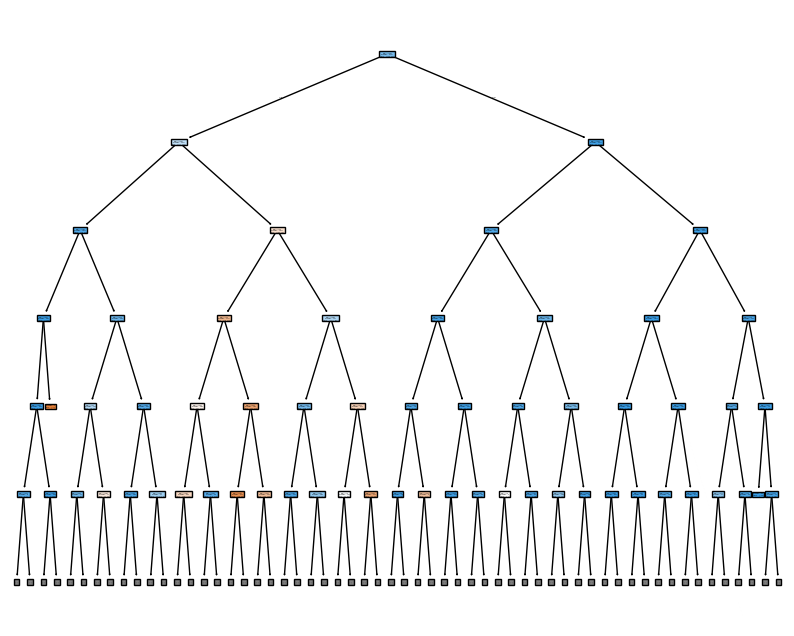

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10,8))
plot_tree(dt, max_depth=5, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

# 프루닝

In [ ]:
dt= DecisionTreeClassifier(
        max_depth=3,
)

dt.fit(train_input, train_target)
print("훈련데이터 : ", dt.score(train_input, train_target))
print("TEST 데이터 : ", dt.score(test_input, test_target))

훈련데이터 :  0.8454877814123533
TEST 데이터 :  0.8415384615384616


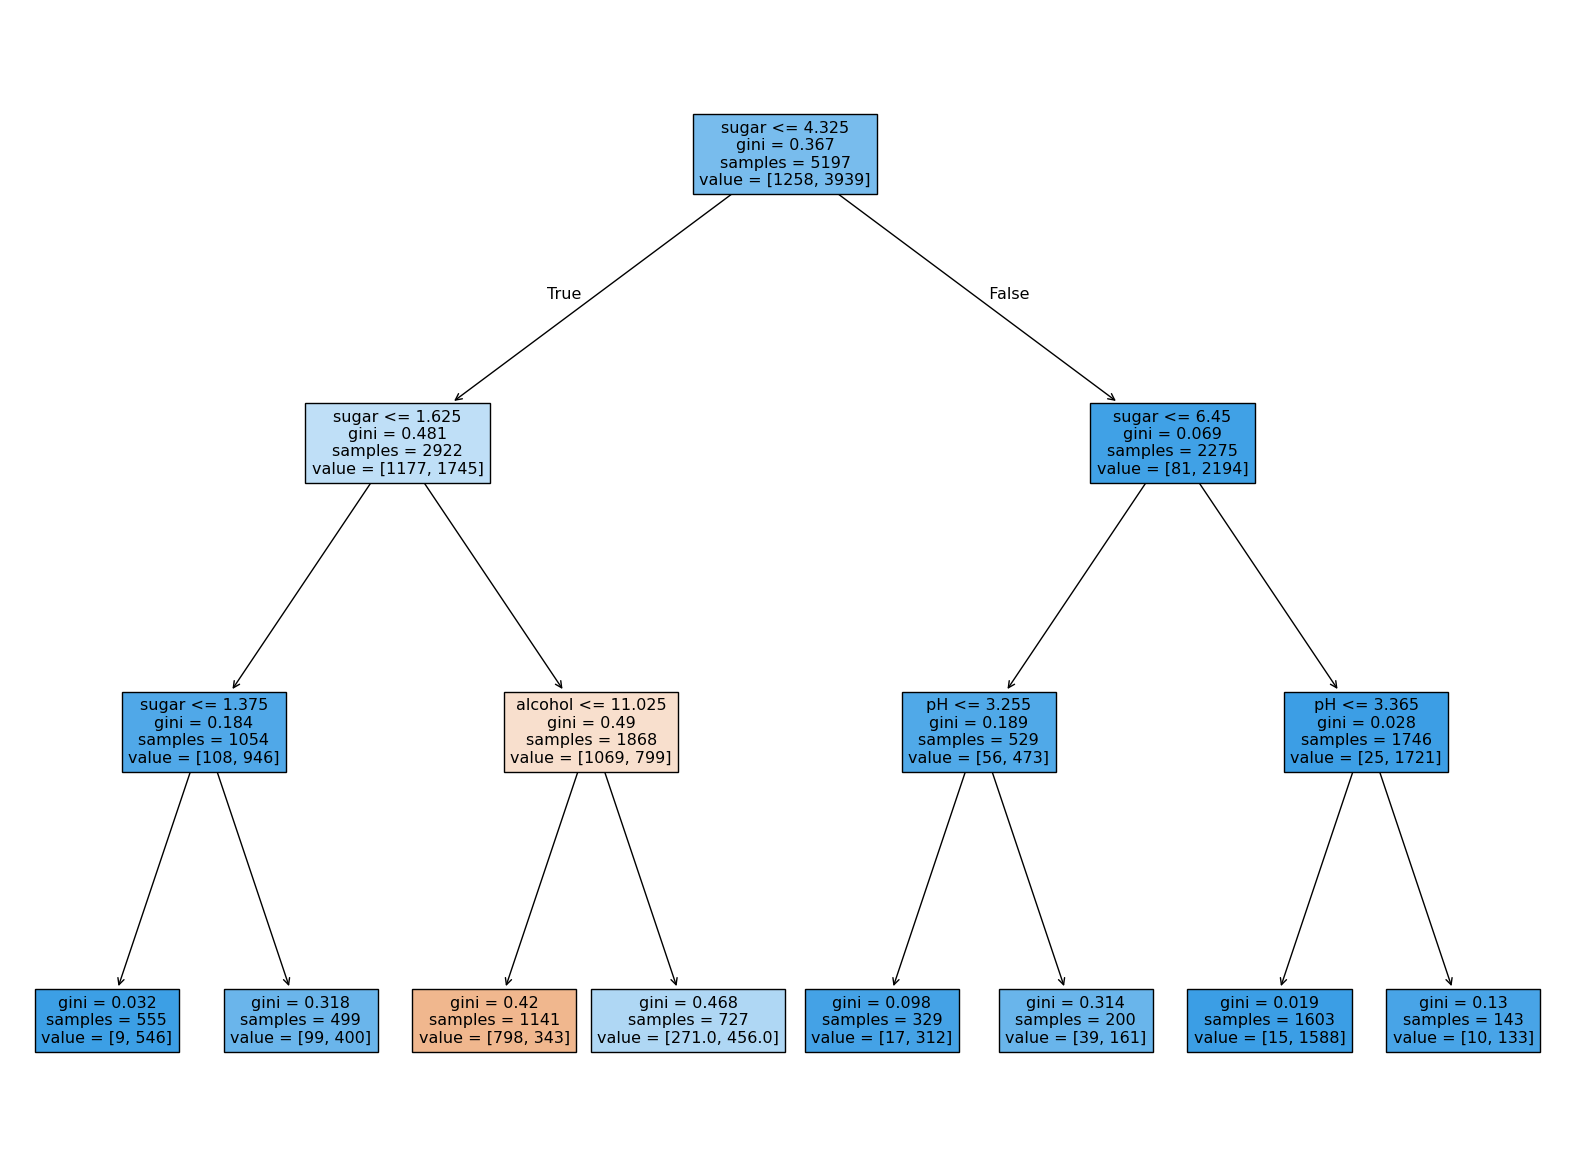

In [ ]:
plt.figure(figsize=(20, 15))
plot_tree(dt, filled=True, feature_names=["alcohol", "sugar", "pH"])
plt.show()

In [ ]:
# 특성별로 중요도를 확인하는 코드이다.
# [알코올, 슈가, pH]
# 아래의 결과를 보면 각각의 중요도는 알코올:12%, 슈가:87%, pH: 0.8%이다.
dt.feature_importances_

array([0.12345626, 0.86862934, 0.0079144 ])

In [ ]:
# 가지치기 최적 depth 찾아보기
for depth in [1, 2, 3, 4, 5, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=1)
    dt.fit(train_input, train_target)
    tr = dt.score(train_input, train_target)
    te = dt.score(test_input, test_target)
    print(f"max_depth={depth} : train={tr}, test={te}")    

max_depth=1 : train=0.7579372715027901, test=0.7376923076923076
max_depth=2 : train=0.8098903213392342, test=0.7961538461538461
max_depth=3 : train=0.8454877814123533, test=0.8415384615384616
max_depth=4 : train=0.8572253223013276, test=0.8484615384615385
max_depth=5 : train=0.8672310948624207, test=0.8607692307692307
max_depth=None : train=0.996921300750433, test=0.8576923076923076


랜덤 포레스트 레츠고!

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate 

rf = RandomForestClassifier()
rf.fit(train_input, train_target)

scores = cross_validate(rf, train_input, train_target)
scores # 학습 시간, 평가 시간, 성능
print(scores['test_score']) #정확도
scores['test_score'].mean()



[0.88076923 0.88076923 0.90567854 0.89701636 0.88931665]


np.float64(0.8907100022210706)

그레디언트 부스트!

In [ ]:
### Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
scores = cross_validate(gb, train_input, train_target, return_train_score=True)

In [ ]:
print(scores['train_score'].mean())
print(scores['test_score'].mean())

0.8881086892152563
0.8720430147331015


In [ ]:
### HistGradient Boosting
# 히스토그램 기반의 Gradient 부스팅이당.
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True)

print(scores['train_score'].mean())
print(scores['test_score'].mean())

0.9321723946453317
0.8801241948619236


<!-- 과적합~~~~~~~ -->

XG부스트 레츠고!

In [ ]:
!pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# XGBoost: 오픈소스 앙상블 모델. Kaggle에서 최상위 솔루션이었음.
from xgboost import XGBClassifier

gb = XGBClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True)

print(scores['train_score'].mean())
print(scores['test_score'].mean())

0.9567059184812372
0.8783915747390243


라이트지비엠!!!!!!!!!@

In [ ]:
!pip install lightgbm


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 36.5 MB/s  0:00:00



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from lightgbm import LGBMClassifier

gb = LGBMClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True)

print(scores['train_score'].mean())
print(scores['test_score'].mean())

[LightGBM] [Info] Number of positive: 3151, number of negative: 1006
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 372
[LightGBM] [Info] Number of data points in the train set: 4157, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.757999 -> initscore=1.141738
[LightGBM] [Info] Start training from score 1.141738


c:\Users\kim\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\kim\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\kim\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\kim\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\kim\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning

[LightGBM] [Info] Number of positive: 3151, number of negative: 1006
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000061 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 370
[LightGBM] [Info] Number of data points in the train set: 4157, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.757999 -> initscore=1.141738
[LightGBM] [Info] Start training from score 1.141738
[LightGBM] [Info] Number of positive: 3151, number of negative: 1007
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000050 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 373
[LightGBM] [Info] Number of data points in the train set: 4158, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.757816 -> initscore=1.140744
[LightGBM] [Info] Start training from score 1.140744
[LightGBM] [Info] Number o

c:\Users\kim\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\kim\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


그리드 서치!

In [ ]:
from sklearn.model_selection import GridSearchCV
params = {
'min_impurity_decrease':
[0.0001, 0.0002, 0.0003, 0.0004, 0.0005],
'max_depth': [3,4,5,6,7,8,9,10,11,12,13,14],
'min_samples_split': [2,3,4,5,6,7,8,9,10,11,12],
}
# 5 × 12 × 11 = 660 조합 × 5폴드 = 3,300번!
gs = GridSearchCV(DecisionTreeClassifier(random_state=42),
params, cv=5, n_jobs=-1)
gs.fit(train_input, train_target)
print(gs.best_params_)   # max_depth:14, ...
print(gs.best_score_)    
# 0.8690

{'max_depth': 14, 'min_impurity_decrease': 0.0004, 'min_samples_split': 8}
0.8689635004071963


In [ ]:
from sklearn.datasets import load_wine
load_wine()

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

Decision_Tree 다시 복습!!

서론
1. 문제 정의
레드와인과 화이트와인을 생산했는데 급하게 제작하는 바람에 화이트와인과 레드와인을 구분하는 표시가 생략되었다.
담당자는 살기 위해 방법을 고안하기 시작한다. 이에 우리 주인공은 캔에 인쇄된 알코올, 당도, pH값으로 와인을 구분하는 
프로젝트를 시작한다.

2. 처음에는 로지스틱 회귀로 와인 분석을 시작한다. 6,497개의 데이터를 받은 우리의 주인공은 pandas를 이용하여 pd.read_csv()표현을 통해 데이터셋을 불러온다. 그리고 wine.head()를 통해 상위 5개값만을 추출하여 데이터의 모양을 확인한다.
그렇게 alcohol, sugar, pH값을 data 값으로 class의 값은 target 값으로 설정한다. 타겟값의로 0이면 레드와인이고 1이면 화이트와인으로 설명을 듣고 이는 화이트와인을 골라내는 싸움이 되겟다는 생각을 합니다.

3. 그리고, 로지스틱 회귀 모델을 훈련하기 전, 데이터프레임을 조금 더 분석하기 위해 data.info()와 data.describe()를 통해 정보를 확인합니다. data.info()로 데이터프레임의 각 열의 데이터 타입과 누락된 데이터를 확인할 수 있습니다.
data.describe()를 통해서는 열에 대하여 최소, 최대, 평균값등의 간략한 통계를 출력할 수 있습니다.

4. data.info()를 파악한 결과, 6497개의 데이터이고 모든 열은 실숫값이고 누락값은 없는 것으로 확인했습니다.

5. data.descirbe()는 평균, 최소, 최대, 표준편차, 중간값, 1사분위수, 3사분위수를 알려줍니다. 그런데 여기서 알코올 도수와 당도, pH값의 스케일이 다른 것을 확인했고, 이를 스케일링 하지 않으면, 정확한 결과가 나올 수 없으므로,StandardScaler클래스를 이용해서 특성을 표준화해야 합니다.

6. 표준화를 위해 판다스 데이터프레임에서 특성과 타깃을 추출하고 훈련세트와 테스트 세트로 나눕니다.
data = wine[['alcohol', 'sugar', 'pH']]
target = wine[['class']]

wine 데이터프레임에 처음 3개의 열을 저장, class열은 target에 저장했습니다.

이제, 훈련세트와 테스트 세트로 나누겠습니다.
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(data, target, test_size=0.2, random_state=42)
*random_state를 42로 지정한 이유는 실습과 결과값이 같도록 하기 위함이라고 합니다.

7. train_test_split 함수는 설정값을 지정하지 않으면, 테스트 세트를 25%로 지정하기에 우리는 샘플 개수가 충분히 많으므로 20%만 test_size=0.2를 통해 지정하였습니다.

8. 이제 만들어진 훈련세트와 테스트 세트의 크기를 확인해보면,
print(train_input.shape, test_input.shape)를 통해 확인할 수 있습니다.

9. 이후 StandardScaler를 통해 전처리를 진행할 수 있습니다. 그리고 이후에 같은 객체를 그대로 사용해 테스트 세트를 변환하겠습니다.
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input) # Data Leakage 방지
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

10. 위의 전처리가 끝나고 이제 표준점수로 변환된 train_scaled와 test_scaled를 사용해 로지스틱 회귀 모델을 훈련합니다.
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

11. 그런데 위의 회귀모델의 훈련값과 테스트 성적이 각각 0.78, 0.77이 나오면서 좋지 않은 결과가 나왔습니다.
훈련과 테스트 성적 모두 좋지 않으니 과소적합의 느낌이 납니다.

12. 이 문제 해결을 위해 규제매개변수 C의 값 변경 혹은 solver 매개변수에서 다른 알고리즘 사용, 다항 특성 추가를 고민하는 주인공입니다. 

13. 일단 상황 보고를 위해 주인공은 보고서를 작성하려 합니다. 그리고 모델 설명을 위해 로지스틱 회귀가 학습한 계수와 절편을 출력합니다.
왜 그럴까요,,?
print(lr.coef_, lr.intercept_)

14. 그리고 보고서를 작성하는 주인공, 그렇게 위의 출력결과는 다음과 같습니다.
대략, [[0.51 1.6 -0.7]] [1.8]이 나왔는데 이는 알코올 도수 값에 0.51을, sugar에 1.6을, pH값에 -0.7을 곱하고 마지막으로 1.8을 더하는 구조입니다.
계산의 값이 0보다 작으면 레드와인, 0보다 크면 화이트와인으로 현재 78%의 정확도를 보인다고 해석할 수 있습니다.

15. 그런데 저 계수 값을 어떻게 학습했는지도 모르고, 그냥 계수의 절댓값 기준으로 알코올과 당도의 값이 높을 수록 화이트와인의 가능성이 높고, pH가 높을 수록 레드와인에 가깝다는 사실밖에 이해를 못하겠습니다. 이와 같이 계수의 의미를 완벽히 이해하기는 쉽지 않고 다항특성까지 추가되면 저는 이해하지 않겠습니다.

16. 이처럼 머신러닝의 결과는 이해하기 쉽지 않기에 우리의 주인공은 상사에게 야지를 먹고 화이트보드에 순서도를 그리면서 이렇게 모델을 구성하라고 하네요.
역시 상사는 싫습니다. 그렇게 주인공은 다른 방법을 생각해내려 노력합니다.

17. 그리고 우리의 주인공 결정트리를 생각해냅니다!! 결정트리는 스무고개와 같은 구조라서 이유를 설명하기 쉽습니다. 질문을 하나씩 던져서 정답과 맞춰가는 겁니다.
데이터를 잘 나눌 수 있는 질문만 있다면, 계속 질문을 추가해서 분석정확도를 높일 수 있습니다. 그리고 다행히도 사이킷런이 결정 트리 알고리즘을 제공합니다.
DecisionTreeClassifier 클래스를 통하여 할 수 있고 방법은 위와 같습니다. 

from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

0.99
0.86

18. 결정트리를 통해 하니까 결과가 훨씬 향상됐습니다!! 그런데 과대적합의 경향이 보이네요.
이번에는 시각화 과정을 통해 상사의 비위를 맞춰줍시다.

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10,7))
plot_tree(dt)
plt.show()

19. 이를 보니 엄청 많은 가지가 보입니다. 보기만 해도 이해를 포기하게 되네요,,
결정트리는 위에서 아래로 이동하는 구조입니다. 맨 위의 노드를 루트노드, 맨 아래 끝에 달린 노드를 리프노드라고 합니다.

20. 위의 그림은 너무 복잡하니께 plot_tree()에서 트리의 깊이를 제한할 수 있습니다.
plot_tree(dt, max_depth=1)과 같이 작성하면 루트 노드를 제외하고 하나의 노드를 더 확장하여 그립니다. 그리고 여기에 filled=True를 적어주면 색깔까지 칠할 수 있습니다. 그리고 여기에 feature_names=['alcohol', 'sugar', 'pH']를 적어주면 특성의 이름까지 전달 가능합니다.

21. plot_tree(dt, max_depth=1, filled=True, feature_names=['alcohol', 'sugar' 'pH'])
이렇게 하면 노드의 특성을 더 잘 이해할 수 있습니다.

22. 노드에는 
테스트조건(feature_names 중 적절한 것들)
불순도(gini)
총 샘플 수(samples)
클래스별 샘플 수(value)

이렇게 보면 정말 스무고개처럼 조건에 부합하면 부합하는 쪽으로 가고 부합하지 않으면 부합하지 않는 쪽으로 이동해서 나뉘어지는 마치 사다리 게임과도 같이 보입니다.

23. 여기서 gini를 살펴보겠습니다.
지니는 불순도를 의미합니다.결정트리 클래스의 criterion 매개변수의 기본값이 지니라고 하는데요. 설명은 길지만 저는 정보가 얼마나 섞여있나를 기준으로 0.5일때 딱 반반이니까 정보가 많이 섞여 있어서 최악이고, 숫자가 점점 낮아질수록 데이터 중에 다른 데이터들이 덜 있는거니까 0이 가장 좋다라고 생각했습니다.
부모와 자식 노드의 불순도 차이를 정보 이득이라고도 한다네요. 

24. 이 알고리즘은 정보이득이 최대가 되도록 데이터를 나눕니다. 이때 지니를 기준으로 사용하는 거죠.

25. 그런데 사이킷런에는 다른 불순도 기준도 존재합니다. 바로 바로 entropy라고 하는데요. entropy는 결정트리 클래스에서 criterion=entropy라고 지정하면 사용할 수 있다네요. 엔트로피 불순도의 차이는 엔트로피 불순도도 지니와 똑같이 노드의 불순도를 측정하지만 지니처럼 제곱을 사용하지 않고 밑이 2인 로그를 사용한다는 점이 있습니다.그리고 둘의 결과 차이는 크지 않다네요,,뭐야,,,,,


26. 결정트리를 정리하자면, 결정트리는 스무고개와 같은데 불순도(지니,엔트로피) 기준을 사용해서 불순도를 최대한 줄이는 정보이득이 최대가 되도록 노드를 분할하며 트리를 이동하고 마지막에 노드의 클래스 비율을 보고 예측을 만듭니다.

27. 그런데 앞의 맨 처음 트리는 제한을 두지 않아서 훈련세트보다 테스트 세트의 점수가 크게 낮았습니다. 그래서 이 문제를 다루어보겠습니다.

28. "가지치기" 과수원에서 열매를 잘 맺게 하기 위해 가지치기를 하는 것처럼 결정트리도 가지치기를 해야합니다.그렇게 하지 않으면 과적합이 일어나니까요. 

29. 가지치기를 하는 방법은 아래와 같습니다.
(1) 자라날 수 있는 트리의 최대 깊이를 지정하는 것입니다.
DecisionTreeClassifier의 max_depth 매개변수를 3으로 지정하면 루트 노드 아래로 최대 3개의 노드까지만 성장하게 됩니다.

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test-target))

이렇게 결과를 확인하면, 훈련세트의 성능은 0.845, 테스트 세트는 0.8415가 나오면 과적합이 많이 해소된 걸 확인할 수 있네요.

그리고 이를 시각화 한다면, 
plt.figure(fig_size=(10,8))
plot_tree(dt, filled=True, feature_names=["alchol", "sugar", "pH"])
plt.show()
루트노드는 0으로 간주하여 루트노드 아래로 3개의 노드가 생기게 됩니다.



